In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from PIL import Image
import math

# 1. 加载模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def visualize_cls_similarity(model, raw_image, patch_size=6,size=64):
    """
    计算并可视化 CLS token 与 Patch tokens 的余弦相似度
    """

    # 3. 预处理图像
    # 注意：这里需要根据你模型训练时的 transform 进行调整
    # 通常 ViT 需要 Resize 到特定大小 (例如 224x224) 并进行归一化
    transform = transforms.Compose([
        transforms.RandomCrop(size=size),
        transforms.Normalize(mean=[0.003918, 0.00564221, 0.00870101, 0.01226911, 0.01992336],
                             std=[0.4310049, 0.27417892, 0.38182727, 0.47646362, 1.3710657]),

    ])

    input_tensor = transform(raw_image).unsqueeze(0).to(device)  # [1, C, H, W]
    trans_img=input_tensor.cpu().numpy().squeeze()
    # 4. 前向传播获取 Tokens
    with torch.no_grad():
        # 尝试直接调用，如果不通请尝试 model.forward_features(input_tensor)
        output = model.forward_features(input_tensor)

    # 5. 提取 CLS 和 Patch Tokens
    cls_token = output['x_norm_patchtokens'][0]  # shape: [Dim]
    patch_tokens = output['x_norm_patchtokens'][0]  # shape: [N_patches, Dim]
    # 6. 计算余弦相似度
    # Cosine Similarity = (A . B) / (|A| * |B|)
    # 先对向量进行 L2 归一化，然后做点积即可得到余弦相似度
    cls_token_norm = F.normalize(cls_token, p=2, dim=0)
    patch_tokens_norm = F.normalize(patch_tokens, p=2, dim=1)

    # 计算点积: [Dim] * [N_patches, Dim]^T -> [N_patches]
    similarity = torch.matmul(patch_tokens_norm, cls_token_norm)
    # 7. 重塑为 2D 网格
    num_patches = similarity.shape[0]
    grid_size = int(math.sqrt(num_patches))

    # 检查是否是完美的平方数 (例如 196 -> 14x14)
    if grid_size * grid_size != num_patches:
        print(f"Warning: Patch count {num_patches} is not a perfect square. Grid reshape might be wrong.")

    heatmap = similarity.reshape(grid_size, grid_size).cpu().numpy()
    # (3) 叠加图 (将热力图插值放大并叠加)
    # 将 raw_image 转换为 numpy 以获取尺寸
    img_np = trans_img
    h, w = img_np.shape[1:]
    # 将热力图缩放到原图尺寸
    heatmap_resized = torch.nn.functional.interpolate(
        torch.tensor(heatmap).unsqueeze(0).unsqueeze(0),
        size=(h, w),
        mode='bicubic',
        align_corners=False
    ).squeeze().numpy()
    # 8. 可视化绘图
    fig, axs = plt.subplots(1, 4, figsize=(15, 5))

    # (1) 原始图像
    axs[0].imshow(raw_image[0], cmap='gray')
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    axs[1].imshow(trans_img[0], cmap='gray')
    axs[1].set_title("Trans Image")
    axs[1].axis('off')

    # (2) 原始热力图 (低分辨率)
    im1 = axs[2].imshow(heatmap, cmap='jet')
    axs[2].set_title(f"Raw Similarity ({grid_size}x{grid_size})")
    plt.colorbar(im1, ax=axs[2])

    axs[3].imshow(trans_img[0])
    axs[3].imshow(heatmap_resized, cmap='jet', alpha=0.5)  # alpha 控制透明度
    axs[3].set_title("Overlay High-Res")
    axs[3].axis('off')

    plt.tight_layout()
    plt.show()

    # 打印统计信息
    print(f"Max Similarity: {heatmap.max():.4f}")
    print(f"Min Similarity: {heatmap.min():.4f}")

In [6]:
from astroclip.astrodino.utils import setup_astrodino

astrodino_ckpt = "/mnt/d/SoftWare/PycharmProjects/pretrained/astrodino_63.ckpt"
# 1. 加载模型（这里以 ResNet50 为例，可替换为你的模型）
model = setup_astrodino("../", astrodino_ckpt, astrodino_config_file="../visualize/config.yaml")

import datasets
dset = datasets.load_from_disk("../../../data/data_g3_z_1k/test_dataset")

RuntimeError: Distributed mode has already been enabled

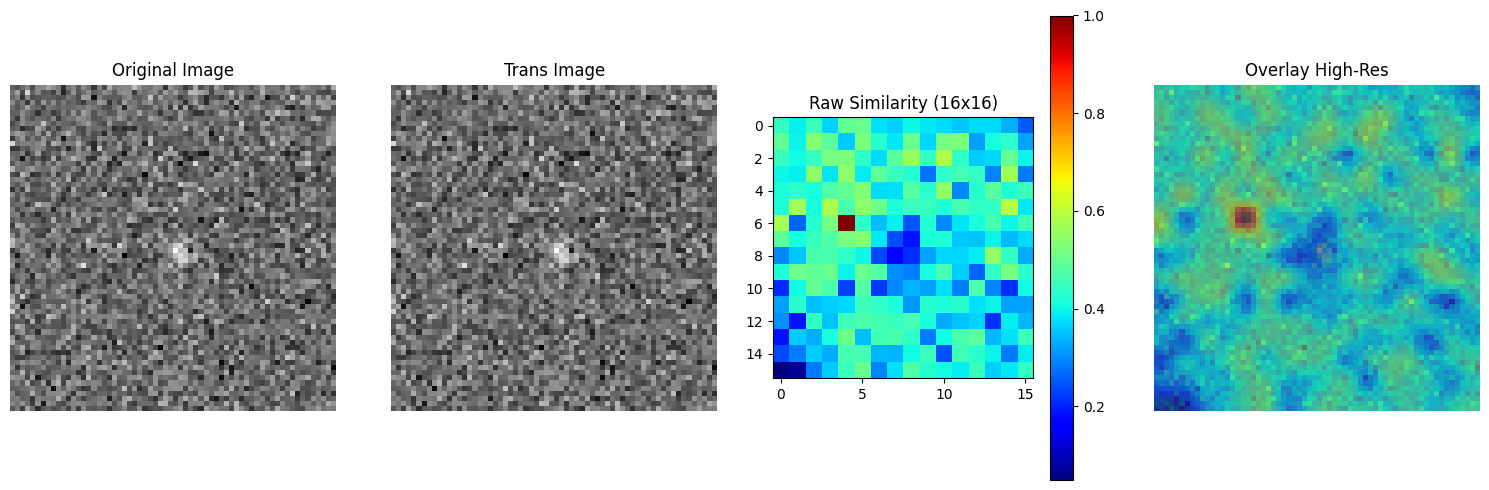

In [22]:
img = dset[0]["image"]
visualize_cls_similarity(model, img, patch_size=4, size=64)